#### Name: Venkatappareddy Manukonda

#### Course: MSCS-634 Advanced Big Data and Data Mining

#### Assignment: Association Rule Mining with Apriori and FP-Growth

## Step 1: Data Preparation and Exploration

The Online Retail dataset contains individual product purchases from customer transactions. Each row represents one item recorded within an invoice, which makes the dataset suitable for market basket analysis. Before applying Apriori and FP-Growth, the data will be examined and cleaned to remove incomplete, cancelled, and invalid transaction records.

In [4]:
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [6]:
# Load the Online Retail dataset
df = pd.read_excel("Online Retail.xlsx")

# Display the first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Explore the Dataset

Before cleaning the transaction records, I examined the dataset’s size, column types, missing values, duplicate rows, and numerical summary. This provides a clearer picture of which records may need to be removed before constructing the market baskets.

In [8]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Review column data types and non-null counts
print("\nDataset information:")
df.info()

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
# Count missing values in each column
print("Missing values:")
display(df.isnull().sum().to_frame(name="Missing Values"))

# Count completely duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Missing values:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Duplicate rows: 5268


In [10]:
# Examine the numerical columns
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


### Data Cleaning

The dataset contains 541,909 item records across eight columns. Product descriptions are missing from 1,454 rows, while CustomerID is missing from 135,080 rows. Since the analysis groups product descriptions by invoice, records without descriptions cannot contribute meaningful items and will be removed. Missing CustomerID values can remain because customer identity is not required for transaction-level association mining.

The numerical summary also reveals negative quantities and prices. Negative quantities commonly represent returned or cancelled purchases rather than completed transactions. To keep the baskets focused on actual purchases, cancelled invoices and records with nonpositive quantities or prices will be excluded. Exact duplicate rows will also be removed to prevent repeated records from distorting item frequencies.

In [11]:
# Create a copy so the original dataset remains unchanged
retail = df.copy()

# Record the original number of rows
original_rows = len(retail)

# Standardize invoice numbers and product descriptions
retail["InvoiceNo"] = retail["InvoiceNo"].astype(str).str.strip()
retail["Description"] = retail["Description"].astype("string").str.strip().str.upper()

# Remove records without a usable product description
retail = retail.dropna(subset=["Description"])
retail = retail[retail["Description"] != ""]

# Remove cancelled invoices, which begin with the letter C
retail = retail[~retail["InvoiceNo"].str.startswith("C")]

# Retain only completed purchases with positive quantity and price
retail = retail[
    (retail["Quantity"] > 0) &
    (retail["UnitPrice"] > 0)
]

# Remove exact duplicate records
retail = retail.drop_duplicates().copy()

# Display the effect of cleaning
print("Rows before cleaning:", original_rows)
print("Rows after cleaning:", len(retail))
print("Rows removed:", original_rows - len(retail))
print("Remaining missing descriptions:", retail["Description"].isnull().sum())
print("Remaining duplicate rows:", retail.duplicated().sum())
print("Minimum quantity:", retail["Quantity"].min())
print("Minimum unit price:", retail["UnitPrice"].min())
print("Remaining cancelled invoices:",
      retail["InvoiceNo"].str.startswith("C").sum())

Rows before cleaning: 541909
Rows after cleaning: 524878
Rows removed: 17031
Remaining missing descriptions: 0
Remaining duplicate rows: 0
Minimum quantity: 1
Minimum unit price: 0.001
Remaining cancelled invoices: 0


### Cleaning Result

After cleaning, the remaining records represent completed purchases with valid product descriptions, positive quantities, and positive prices. Cancelled invoices and duplicate records were excluded so that returns and repeated entries would not influence product frequencies or association rules. CustomerID was not used as a cleaning requirement because the market baskets are constructed from invoice numbers.

### Transaction Scope

The Online Retail dataset includes purchases from several countries. Examining the number of invoices by country helps determine whether the analysis should use the entire dataset or focus on a sufficiently large market. The dataset is also checked for administrative entries, such as postage and bank charges, because these entries are not regular retail products and may produce less useful association rules.

In [12]:
# Count unique invoices by country
country_summary = (
    retail.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Transactions")
)

country_summary.head(10)

,Country,Transactions
0,United Kingdom,18019
1,Germany,457
2,France,392
3,EIRE,288
4,Belgium,98
5,Netherlands,94
6,Spain,90
7,Portugal,58
8,Australia,57
9,Switzerland,54


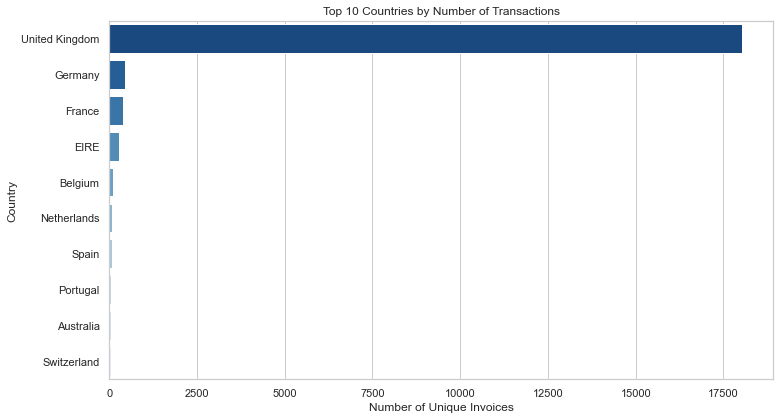

In [13]:
# Visualize the countries with the largest numbers of transactions
plt.figure(figsize=(11, 6))

sns.barplot(
    data=country_summary.head(10),
    x="Transactions",
    y="Country",
    palette="Blues_r"
)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Unique Invoices")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [14]:
# Search for common administrative or service-related entries
administrative_terms = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "BANK CHARGES",
    "AMAZON FEE",
    "CARRIAGE",
    "MANUAL",
    "ADJUST",
    "DISCOUNT"
]

administrative_entries = retail[
    retail["Description"].str.contains(
        "|".join(administrative_terms),
        case=False,
        na=False
    )
]

administrative_entries["Description"].value_counts().head(20)

POSTAGE                         1126
DOTCOM POSTAGE                   706
MANUAL                           317
CARRIAGE                         141
NEXT DAY CARRIAGE                 79
FRENCH CARRIAGE LANTERN           59
BLACK BAROQUE CARRIAGE CLOCK      35
BANK CHARGES                      12
AMAZON FEE                         2
ADJUST BAD DEBT                    1
Name: Description, dtype: Int64

### Selection of Transaction Scope

The United Kingdom contains 18,019 unique invoices, far more than any other country in the dataset. I selected this market because it provides enough transactions to identify stable purchasing patterns while avoiding possible differences in product availability across countries. Limiting the analysis to one market also reduces the size of the transaction matrix, which is especially important for Apriori.

Administrative descriptions were removed using exact matches rather than keyword matching. This prevents legitimate products, such as carriage-themed lanterns or clocks, from being removed accidentally.

In [15]:
# Select United Kingdom transactions
uk_retail = retail[retail["Country"] == "United Kingdom"].copy()

# Remove entries that represent fees or administrative adjustments
non_product_descriptions = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "MANUAL",
    "CARRIAGE",
    "NEXT DAY CARRIAGE",
    "BANK CHARGES",
    "AMAZON FEE",
    "ADJUST BAD DEBT"
]

uk_retail = uk_retail[
    ~uk_retail["Description"].isin(non_product_descriptions)
].copy()

print("UK item records:", len(uk_retail))
print("UK transactions:", uk_retail["InvoiceNo"].nunique())
print("Unique products:", uk_retail["Description"].nunique())

UK item records: 478828
UK transactions: 17903
Unique products: 3988


### Most Frequently Purchased Items

Item frequency is measured by the number of unique invoices containing each product rather than the total quantity sold. This approach matches association rule mining, where the main concern is whether an item appears in a basket, not how many units were purchased.

In [16]:
# Count the number of unique transactions containing each item
item_frequency = (
    uk_retail.groupby("Description")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Transaction Count")
)

item_frequency

,Description,Transaction Count
0,WHITE HANGING HEART T-LIGHT HOLDER,2162
1,JUMBO BAG RED RETROSPOT,1935
2,REGENCY CAKESTAND 3 TIER,1685
3,PARTY BUNTING,1593
4,LUNCH BAG RED RETROSPOT,1392
5,ASSORTED COLOUR BIRD ORNAMENT,1371
6,SET OF 3 CAKE TINS PANTRY DESIGN,1241
7,NATURAL SLATE HEART CHALKBOARD,1219
8,LUNCH BAG BLACK SKULL.,1216
9,HEART OF WICKER SMALL,1164


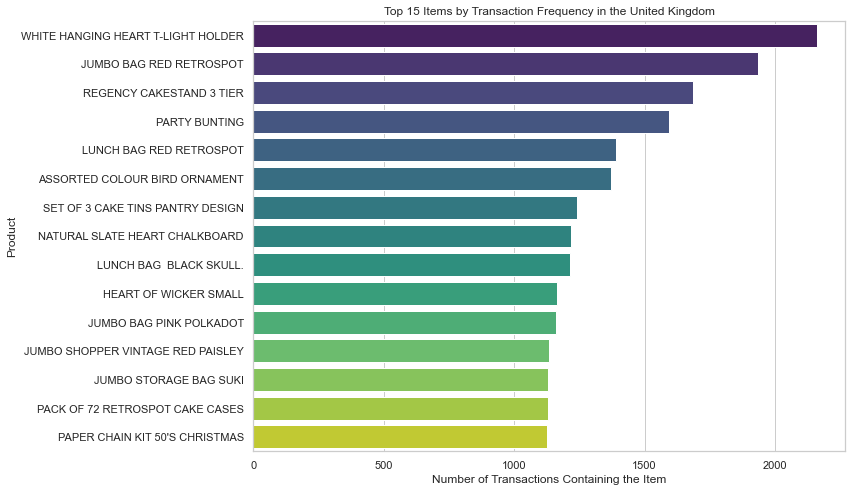

In [17]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=item_frequency,
    x="Transaction Count",
    y="Description",
    palette="viridis"
)

plt.title("Top 15 Items by Transaction Frequency in the United Kingdom")
plt.xlabel("Number of Transactions Containing the Item")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Item Co-occurrence

The co-occurrence analysis measures how often two popular products appear within the same invoice. Unlike the earlier frequency chart, this visualization focuses on product pairs. The diagonal is excluded because it only represents the frequency of each item with itself.

In [18]:
# Select the 10 most frequent products
top_10_items = item_frequency.head(10)["Description"].tolist()

# Keep only records containing one of the top 10 products
top_items_data = uk_retail[
    uk_retail["Description"].isin(top_10_items)
]

# Create a binary invoice-item matrix
top_item_basket = pd.crosstab(
    top_items_data["InvoiceNo"],
    top_items_data["Description"]
)

top_item_basket = (top_item_basket > 0).astype(int)

print("Top-item basket shape:", top_item_basket.shape)
top_item_basket.head()

Top-item basket shape: (8297, 10)


Description,ASSORTED COLOUR BIRD ORNAMENT,HEART OF WICKER SMALL,JUMBO BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,NATURAL SLATE HEART CHALKBOARD,PARTY BUNTING,REGENCY CAKESTAND 3 TIER,SET OF 3 CAKE TINS PANTRY DESIGN,WHITE HANGING HEART T-LIGHT HOLDER
InvoiceNo,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,1
536367,1,0,0,0,0,0,0,0,0,0
536373,0,0,0,0,0,0,0,0,0,1
536375,0,0,0,0,0,0,0,0,0,1
536378,0,0,0,0,1,0,0,0,0,0


In [19]:
# Count how many invoices contain each pair of products
cooccurrence = top_item_basket.T.dot(top_item_basket)

# Remove the diagonal because it represents individual item frequency
cooccurrence_display = cooccurrence.astype(float)
np.fill_diagonal(cooccurrence_display.values, np.nan)

cooccurrence_display

Description,ASSORTED COLOUR BIRD ORNAMENT,HEART OF WICKER SMALL,JUMBO BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,NATURAL SLATE HEART CHALKBOARD,PARTY BUNTING,REGENCY CAKESTAND 3 TIER,SET OF 3 CAKE TINS PANTRY DESIGN,WHITE HANGING HEART T-LIGHT HOLDER
Description,,,,,,,,,,
ASSORTED COLOUR BIRD ORNAMENT,NaN,144.0,156.0,119.0,149.0,175.0,225.0,239.0,150.0,305.0
HEART OF WICKER SMALL,144.0,NaN,253.0,153.0,192.0,291.0,207.0,190.0,188.0,375.0
JUMBO BAG RED RETROSPOT,156.0,253.0,NaN,365.0,531.0,315.0,315.0,258.0,289.0,436.0
LUNCH BAG BLACK SKULL.,119.0,153.0,365.0,NaN,607.0,158.0,246.0,219.0,139.0,259.0
LUNCH BAG RED RETROSPOT,149.0,192.0,531.0,607.0,NaN,215.0,306.0,248.0,206.0,324.0
NATURAL SLATE HEART CHALKBOARD,175.0,291.0,315.0,158.0,215.0,NaN,248.0,224.0,233.0,410.0
PARTY BUNTING,225.0,207.0,315.0,246.0,306.0,248.0,NaN,364.0,236.0,378.0
REGENCY CAKESTAND 3 TIER,239.0,190.0,258.0,219.0,248.0,224.0,364.0,NaN,262.0,336.0
SET OF 3 CAKE TINS PANTRY DESIGN,150.0,188.0,289.0,139.0,206.0,233.0,236.0,262.0,NaN,310.0


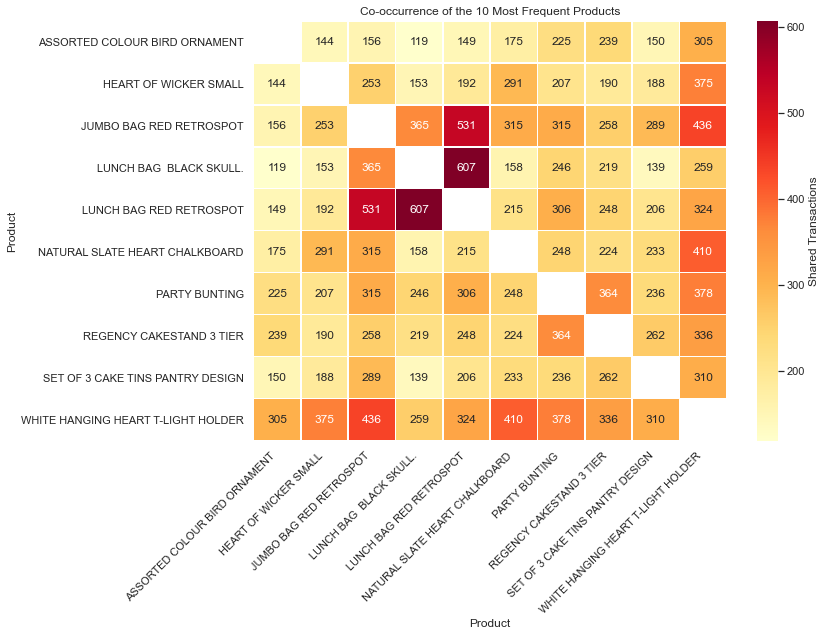

In [20]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    cooccurrence_display,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Shared Transactions"}
)

plt.title("Co-occurrence of the 10 Most Frequent Products")
plt.xlabel("Product")
plt.ylabel("Product")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# Extract the strongest unique product pairs
pair_records = []

for i in range(len(cooccurrence.columns)):
    for j in range(i + 1, len(cooccurrence.columns)):
        pair_records.append({
            "Item 1": cooccurrence.index[i],
            "Item 2": cooccurrence.columns[j],
            "Shared Transactions": cooccurrence.iloc[i, j]
        })

strongest_pairs = (
    pd.DataFrame(pair_records)
    .sort_values("Shared Transactions", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

strongest_pairs

,Item 1,Item 2,Shared Transactions
0,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,607
1,JUMBO BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT,531
2,JUMBO BAG RED RETROSPOT,WHITE HANGING HEART T-LIGHT HOLDER,436
3,NATURAL SLATE HEART CHALKBOARD,WHITE HANGING HEART T-LIGHT HOLDER,410
4,PARTY BUNTING,WHITE HANGING HEART T-LIGHT HOLDER,378
5,HEART OF WICKER SMALL,WHITE HANGING HEART T-LIGHT HOLDER,375
6,JUMBO BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,365
7,PARTY BUNTING,REGENCY CAKESTAND 3 TIER,364
8,REGENCY CAKESTAND 3 TIER,WHITE HANGING HEART T-LIGHT HOLDER,336
9,LUNCH BAG RED RETROSPOT,WHITE HANGING HEART T-LIGHT HOLDER,324


### Step 1 Observations

The initial exploration showed that the United Kingdom dominates the dataset with 18,019 invoices before administrative entries were removed. After limiting the analysis to completed UK purchases and excluding non-product charges, 17,903 transactions and 3,988 unique products remained.

The frequency chart shows that the White Hanging Heart T-Light Holder was the most widely purchased product, appearing in 2,162 transactions. The co-occurrence analysis adds more detail by showing which popular products were purchased together. The strongest pair was Lunch Bag Black Skull and Lunch Bag Red Retrospot, which appeared together in 607 invoices. This relationship is reasonable because the items serve the same purpose but have different designs. Other recurring combinations involve jumbo bags, lunch bags, decorative heart products, and party items. These results provide an early indication that product style and function may influence joint purchases.

### Transaction Basket Preparation

Apriori and FP-Growth require a binary transaction matrix in which each row represents an invoice and each column represents a product. A value of True means the product appeared in the invoice, while False means it did not.

Products appearing in fewer than 1% of transactions are excluded before constructing the matrix. An item below this frequency cannot meet any of the support thresholds that will be tested. This reduces unnecessary columns without removing any product capable of becoming a frequent itemset.

In [24]:
# Store every valid invoice so the support denominator remains accurate
all_invoices = uk_retail["InvoiceNo"].unique()
number_of_transactions = len(all_invoices)

# Keep products appearing in at least 1% of transactions
minimum_item_count = int(np.ceil(number_of_transactions * 0.01))

product_transaction_counts = (
    uk_retail.groupby("Description")["InvoiceNo"].nunique()
)

eligible_products = product_transaction_counts[
    product_transaction_counts >= minimum_item_count
].index

print("Number of transactions:", number_of_transactions)
print("Minimum transaction count for an item:", minimum_item_count)
print("Products retained:", len(eligible_products))

Number of transactions: 17903
Minimum transaction count for an item: 180
Products retained: 815


In [26]:
# Keep only products that can meet the lowest tested support
basket_data = uk_retail[
    uk_retail["Description"].isin(eligible_products)
]

# Create the invoice-product matrix
basket = pd.crosstab(
    basket_data["InvoiceNo"],
    basket_data["Description"]
)

# Restore invoices that contained none of the retained products
basket = basket.reindex(all_invoices, fill_value=0)

# Convert quantities into presence or absence
basket = basket.astype(bool)

print("Transaction basket shape:", basket.shape)
print("Basket data type:", basket.dtypes.iloc[0])
basket.iloc[:5, :10]

Transaction basket shape: (17903, 815)
Basket data type: bool


Description,10 COLOUR SPACEBOY PEN,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,12 PENCILS TALL TUBE WOODLAND,15CM CHRISTMAS GLASS BALL 20 LIGHTS,20 DOLLY PEGS RETROSPOT
InvoiceNo,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False


## Step 2: Frequent Itemset Mining Using Apriori

Apriori identifies frequent product combinations by evaluating whether their support meets a selected threshold. Support represents the proportion of transactions containing an itemset. A threshold that is too high may return only individual products, while an extremely low threshold can produce too many weak combinations and increase processing time.

To make the selection evidence-based, support values of 1%, 2%, and 3% will be evaluated. The number of frequent itemsets and execution time will be compared before choosing the final threshold.

In [27]:
# Test several support thresholds with Apriori
support_values = [0.03, 0.02, 0.01]
apriori_results = []
apriori_itemsets_by_support = {}

for support_value in support_values:
    start_time = time.perf_counter()

    itemsets = apriori(
        basket,
        min_support=support_value,
        use_colnames=True,
        low_memory=True
    )

    elapsed_time = time.perf_counter() - start_time

    # Store each result for later comparison
    apriori_itemsets_by_support[support_value] = itemsets

    apriori_results.append({
        "Minimum Support": support_value,
        "Minimum Transactions": int(
            np.ceil(support_value * len(basket))
        ),
        "Frequent Itemsets": len(itemsets),
        "Execution Time (Seconds)": elapsed_time
    })

apriori_support_summary = pd.DataFrame(apriori_results)
apriori_support_summary

,Minimum Support,Minimum Transactions,Frequent Itemsets,Execution Time (Seconds)
0,0.03,538,146,0.766586
1,0.02,359,399,1.814957
2,0.01,180,2057,5.533643


### Support Threshold Selection

The support experiment showed a clear trade-off between detail and computational cost. At 3% support, Apriori found only 146 itemsets, which may overlook useful product combinations. Lowering the threshold to 1% increased the output to 2,057 itemsets and required about 5.53 seconds. Although this produced more patterns, many involved products appearing in a relatively small share of transactions.

A minimum support of 2% was selected as a balanced choice. An itemset must therefore appear in at least 359 of the 17,903 transactions. This threshold produced 399 frequent itemsets in approximately 1.81 seconds, preserving meaningful combinations without creating an unnecessarily large result.

In [28]:
# Select and prepare Apriori results at 2% support
selected_support = 0.02

apriori_itemsets = apriori_itemsets_by_support[selected_support].copy()
apriori_itemsets["Length"] = apriori_itemsets["itemsets"].apply(len)
apriori_itemsets["Itemset"] = apriori_itemsets["itemsets"].apply(
    lambda items: ", ".join(sorted(items))
)

# Display the 15 most frequent product combinations
top_apriori = (
    apriori_itemsets[apriori_itemsets["Length"] >= 2]
    .sort_values("support", ascending=False)
    .head(15)
)

top_apriori[["Itemset", "support", "Length"]]

,Itemset,support,Length
329,"JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",0.043847,2
314,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.039100,2
342,"JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI",0.038988,2
340,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE RED PAISLEY",0.036698,2
355,"LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROSPOT",0.033905,2
312,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.032173,2
319,"JUMBO BAG BAROQUE BLACK WHITE, JUMBO BAG RED RETROSPOT",0.031838,2
301,"ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE RED",0.031447,2
366,"LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROSPOT",0.030945,2
383,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.030442,2


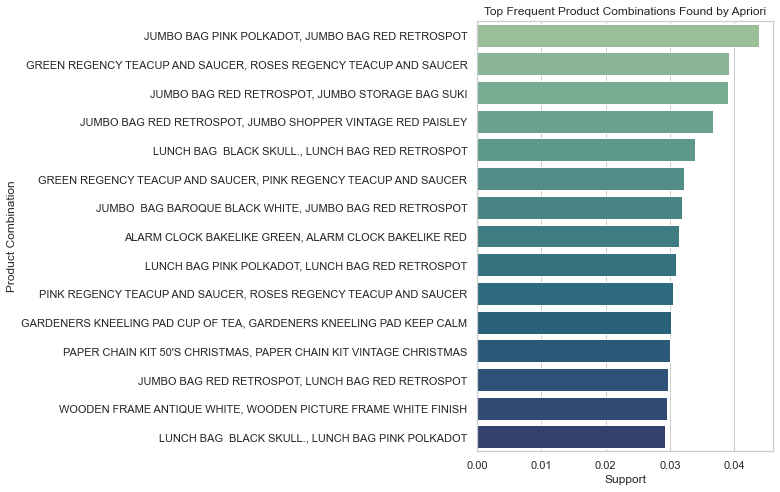

In [29]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_apriori,
    x="support",
    y="Itemset",
    palette="crest"
)

plt.title("Top Frequent Product Combinations Found by Apriori")
plt.xlabel("Support")
plt.ylabel("Product Combination")
plt.tight_layout()
plt.show()

## Step 3: Frequent Itemset Mining Using FP-Growth

FP-Growth was applied using the same 2% minimum support selected for Apriori. Keeping the transaction matrix and support threshold unchanged allows the algorithms to be compared fairly. Execution time was measured to evaluate whether FP-Growth processed the dataset more efficiently.

In [30]:
# Run FP-Growth using the same support threshold
start_time = time.perf_counter()

fp_itemsets = fpgrowth(
    basket,
    min_support=selected_support,
    use_colnames=True
)

fp_time = time.perf_counter() - start_time

fp_itemsets["Length"] = fp_itemsets["itemsets"].apply(len)
fp_itemsets["Itemset"] = fp_itemsets["itemsets"].apply(
    lambda items: ", ".join(sorted(items))
)

print("FP-Growth itemsets:", len(fp_itemsets))
print("FP-Growth execution time:", round(fp_time, 4), "seconds")

FP-Growth itemsets: 399
FP-Growth execution time: 9.732 seconds


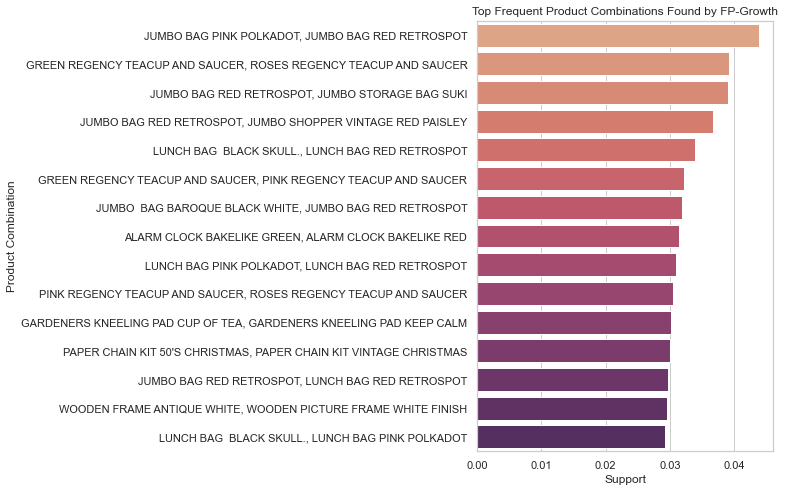

,Itemset,support,Length
305,"JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",0.043847,2
359,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.039100,2
307,"JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI",0.038988,2
324,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE RED PAISLEY",0.036698,2
349,"LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROSPOT",0.033905,2
379,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.032173,2
313,"JUMBO BAG BAROQUE BLACK WHITE, JUMBO BAG RED RETROSPOT",0.031838,2
327,"ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE RED",0.031447,2
338,"LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROSPOT",0.030945,2
380,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.030442,2


In [31]:
top_fp = (
    fp_itemsets[fp_itemsets["Length"] >= 2]
    .sort_values("support", ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_fp,
    x="support",
    y="Itemset",
    palette="flare"
)

plt.title("Top Frequent Product Combinations Found by FP-Growth")
plt.xlabel("Support")
plt.ylabel("Product Combination")
plt.tight_layout()
plt.show()

top_fp[["Itemset", "support", "Length"]]

### FP-Growth Results

FP-Growth produced 399 frequent itemsets using the same 2% support threshold as Apriori. The most frequent combination was Jumbo Bag Pink Polkadot with Jumbo Bag Red Retrospot, appearing in approximately 4.38% of transactions. Several leading combinations involve different designs from the same product family, including jumbo bags, lunch bags, teacups, alarm clocks, and paper-chain kits. This suggests that customers often purchase coordinated designs or multiple variations of products with similar uses.

In [32]:
# Confirm whether both algorithms found the same itemsets
apriori_sets = set(apriori_itemsets["itemsets"])
fp_sets = set(fp_itemsets["itemsets"])

comparison = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Frequent Itemsets": [len(apriori_itemsets), len(fp_itemsets)],
    "Execution Time (Seconds)": [1.814957, fp_time]
})

print("Identical itemsets:", apriori_sets == fp_sets)
comparison

Identical itemsets: True


,Algorithm,Frequent Itemsets,Execution Time (Seconds)
0,Apriori,399,1.814957
1,FP-Growth,399,9.732006


### Initial Algorithm Comparison

Apriori and FP-Growth returned the same 399 frequent itemsets, confirming that both algorithms produced consistent results under the same support threshold. Apriori completed the analysis faster in this experiment. Although FP-Growth is often more efficient on large and highly repetitive transaction data, its tree-building process introduced additional overhead for this filtered basket. The result shows that algorithm performance depends on the structure of the data and the implementation, not only on the general theoretical advantages of each method.

## Step 4: Generating and Analyzing Association Rules

Association rules were generated using a minimum confidence of 50%. This threshold requires the consequent to occur in at least half of the transactions containing the antecedent. Rules are evaluated using support, confidence, and lift. Lift values above 1 indicate that the products occur together more often than expected if their purchases were independent.

In [33]:
# Generate rules from both sets of frequent itemsets
confidence_threshold = 0.50

apriori_rules = association_rules(
    apriori_itemsets,
    metric="confidence",
    min_threshold=confidence_threshold
)

fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=confidence_threshold
)

print("Apriori rules:", len(apriori_rules))
print("FP-Growth rules:", len(fp_rules))

Apriori rules: 75
FP-Growth rules: 75


In [34]:
# Create readable rule labels
rules_display = apriori_rules.copy()

rules_display["Antecedent"] = rules_display["antecedents"].apply(
    lambda items: ", ".join(sorted(items))
)

rules_display["Consequent"] = rules_display["consequents"].apply(
    lambda items: ", ".join(sorted(items))
)

top_rules = (
    rules_display
    .sort_values(["lift", "confidence"], ascending=False)
    .head(15)
)

top_rules[
    ["Antecedent", "Consequent", "support", "confidence", "lift"]
].round(4)

,Antecedent,Consequent,support,confidence,lift
56,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.0206,0.7683,27.0222
57,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.0206,0.7230,27.0222
58,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",PINK REGENCY TEACUP AND SAUCER,0.0275,0.7029,17.9249
63,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.0275,0.7009,17.9249
59,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.0275,0.9028,17.3412
62,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER",0.0275,0.5279,17.3412
60,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.0275,0.8542,15.9960
61,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.0275,0.5146,15.9960
20,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0322,0.8205,15.7614
19,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0322,0.6180,15.7614


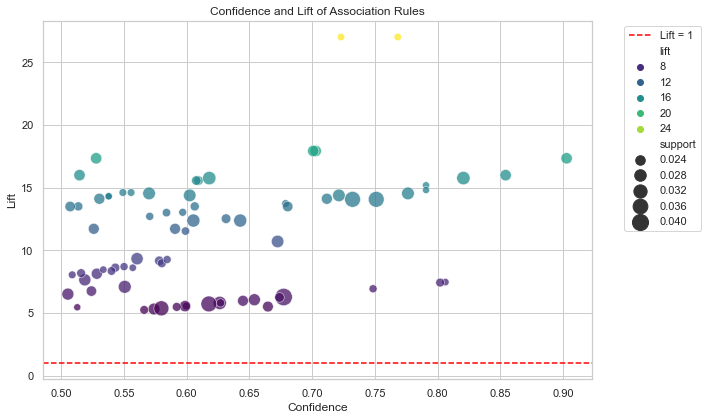

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rules_display,
    x="confidence",
    y="lift",
    size="support",
    hue="lift",
    palette="viridis",
    sizes=(50, 300),
    alpha=0.75
)

plt.axhline(1, color="red", linestyle="--", label="Lift = 1")
plt.title("Confidence and Lift of Association Rules")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Association Rule Interpretation

The strongest relationship involved Wooden Star Christmas Scandinavian and Wooden Heart Christmas Scandinavian. When the star appeared in a transaction, the heart also appeared approximately 76.83% of the time. The rule’s lift of 27.02 indicates that this pairing occurred far more often than would be expected from the individual popularity of the products. The reverse rule was also strong, although its lower confidence of 72.30% shows that direction still matters.

The Regency teacup collection produced several high-lift rules. For example, transactions containing the pink and rose designs also contained the green design about 90.28% of the time. This suggests that customers frequently purchased the coordinated teacup designs as a group. The Spaceboy and Dolly Girl lunch boxes also formed a balanced relationship, with confidence close to 61% in both directions.

The scatter plot shows that all retained rules exceed the 50% confidence threshold and have lift above 1. However, high lift alone should not be treated as proof that one purchase causes another. These results identify purchasing relationships that may support product recommendations, coordinated displays, or bundle testing.

## Step 5: Comparative Analysis

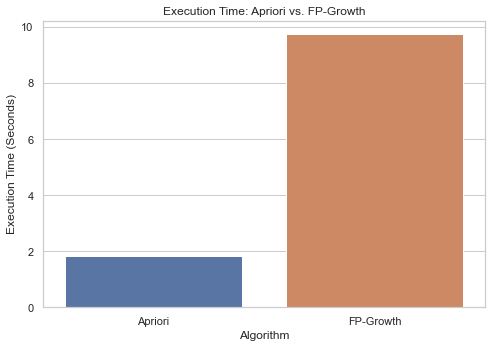

,Algorithm,Frequent Itemsets,Execution Time (Seconds)
0,Apriori,399,1.815
1,FP-Growth,399,9.732


In [36]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Execution Time (Seconds)",
    palette=["#4C72B0", "#DD8452"]
)

plt.title("Execution Time: Apriori vs. FP-Growth")
plt.xlabel("Algorithm")
plt.ylabel("Execution Time (Seconds)")
plt.tight_layout()
plt.show()

comparison.round(4)

### Comparison of Apriori and FP-Growth

Apriori and FP-Growth each identified 399 frequent itemsets and generated 75 association rules. Their matching outputs confirm that both methods analyzed the same transaction structure consistently under the 2% support threshold. The difference was therefore computational rather than analytical.

Apriori completed the task in approximately 1.81 seconds, while FP-Growth required about 9.73 seconds. Apriori was faster for this dataset because filtering reduced the basket to 815 products and the 2% threshold limited the number of qualifying combinations. Under these conditions, Apriori did not need to evaluate an unmanageable number of candidates. FP-Growth avoided candidate generation, but constructing and processing its compressed tree introduced more overhead than it saved. This result does not mean Apriori is always faster. FP-Growth may have a clearer advantage when support is lower or when the dataset contains more repeated and complex baskets.

### Challenges and Decisions

One challenge was the size and quality of the original retail data. Cancelled invoices, missing product descriptions, duplicate records, negative values, and administrative charges could have produced misleading patterns. These records were handled before the transaction baskets were created. Administrative entries were removed through exact matches so that legitimate products containing terms such as “carriage” were preserved.

Another decision involved the support threshold. A 1% threshold produced 2,057 itemsets, while 3% returned only 146. I selected 2% because its 399 itemsets provided enough variety for meaningful rules without making the analysis unnecessarily large. Products appearing in fewer than 1% of transactions were excluded before basket construction because they could not satisfy any tested support threshold. This reduced memory use while preserving all potentially frequent products.

## Conclusion

This analysis showed that association rule mining can reveal purchasing patterns that are not obvious from product frequency alone. Apriori and FP-Growth found the same frequent itemsets and rules, but Apriori performed faster on the filtered UK retail basket. The strongest rules mainly involved coordinated product designs, including Scandinavian Christmas decorations, Regency teacups, lunch boxes, and storage bags.

Support, confidence, and lift provided different perspectives on each pattern. Support showed how widely a combination occurred, confidence measured the reliability of a directional rule, and lift indicated whether the relationship was stronger than ordinary product popularity would suggest. Together, these measures produced a more balanced interpretation than relying on one metric alone. The results could inform recommendation systems, product bundles, and coordinated merchandising, although the observed associations should not be interpreted as causal relationships.